<a href="https://colab.research.google.com/github/foezhasa/Business-Insights-Analysis/blob/main/Business_Insights_from_Customer_Segmentation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Description

This project analyzes customer behavior using demographic and financial data to identify distinct spending patterns and customer segments.

By exploring relationships between income, age, profession, and spending score, the analysis aims to uncover actionable insights that can support targeted marketing strategies and improve customer engagement.

The project applies data cleaning, exploratory data analysis (EDA), and segmentation techniques to better understand customer profiles and business opportunities.

# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

# **LOAD DATA**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Shop_Customer_Data.csv to Shop_Customer_Data.csv


In [4]:
df = pd.read_csv("Shop_Customer_Data.csv")

df.head()
df.shape

(2000, 8)

# **EXPLORE DATA**

In [5]:
df.columns
df.dtypes
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


# **DATA WRANGLING**

In [6]:
# missing values
df.isnull().sum()

# duplicates
df.drop_duplicates(inplace=True)

# **FEATURE ENGINEERING**

# 1. Income Category

In [7]:
df['Income_Category'] = pd.cut(df['Annual Income ($)'],
                              bins=[0,30000,60000,100000,200000],
                              labels=['Low','Medium','High','Very High'])

# 2. Spending Category

In [8]:
df['Spending_Category'] = pd.cut(df['Spending Score (1-100)'],
                                bins=[0,40,70,100],
                                labels=['Low','Medium','High'])

# **EDA**

# 1. Age Distribution

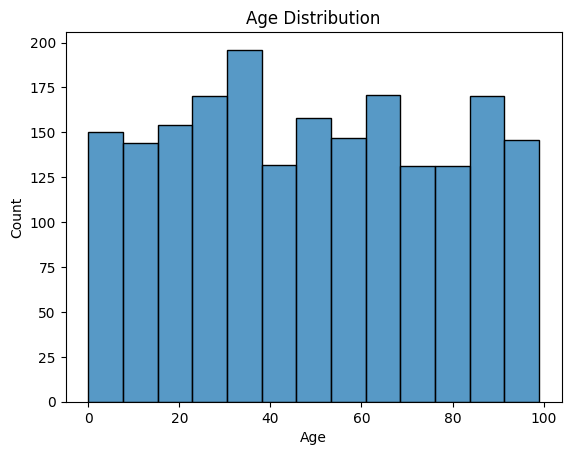

In [9]:
sns.histplot(df['Age'])
plt.title("Age Distribution")
plt.show()

# 2. Income Distribution

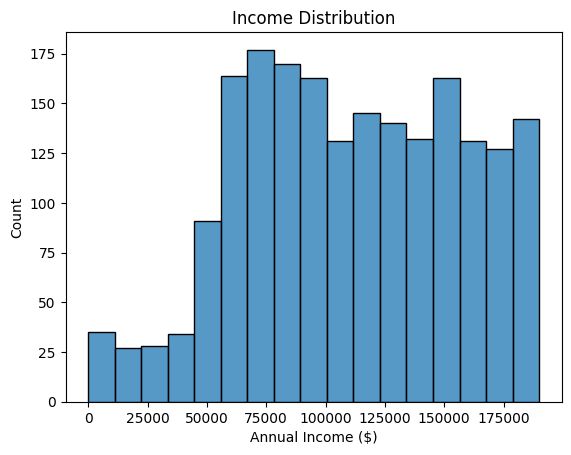

In [10]:
sns.histplot(df['Annual Income ($)'])
plt.title("Income Distribution")
plt.show()

# 3. Spending Score Distribution

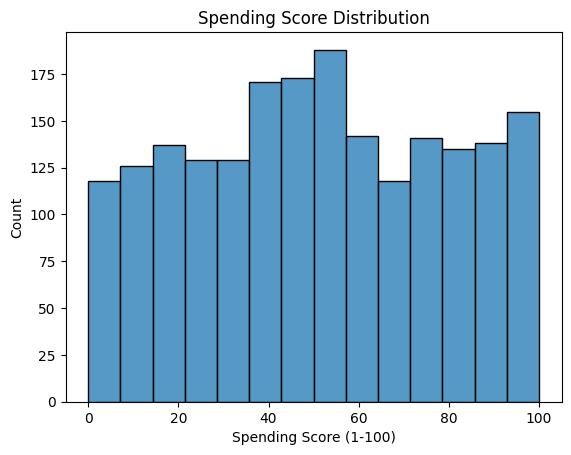

In [11]:
sns.histplot(df['Spending Score (1-100)'])
plt.title("Spending Score Distribution")
plt.show()

# 4. Gender Distribution

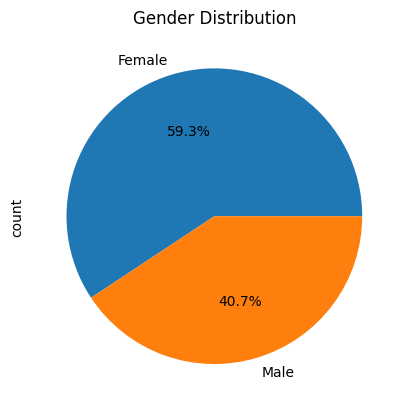

In [12]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

# **RELATIONSHIPS**

# 1. Income vs Spending

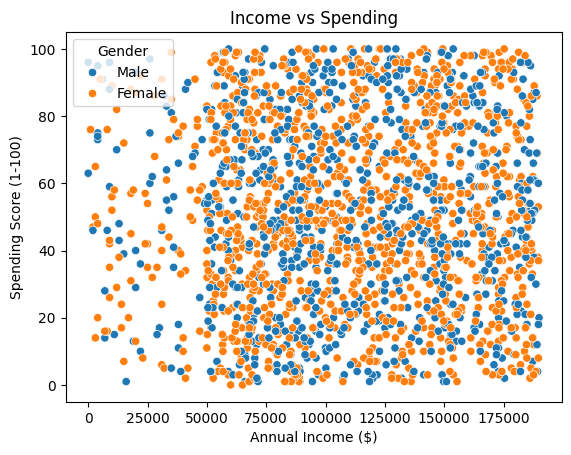

In [13]:
sns.scatterplot(data=df, x='Annual Income ($)', y='Spending Score (1-100)', hue='Gender')
plt.title("Income vs Spending")
plt.show()

#Interpretation of Income vs Spending


The relationship between income and spending score is highly dispersed, indicating no direct linear relationship.
High-income customers are found in both high-spending and low-spending groups, meaning wealth does not guarantee spending.
Similarly, lower-income customers also appear in higher spending segments.
Gender distribution shows no major visible difference between male and female spending behavior.

#Conclusion
Income is not the sole driver of spending — behavioral factors are more important.

# 2. Age vs Spending

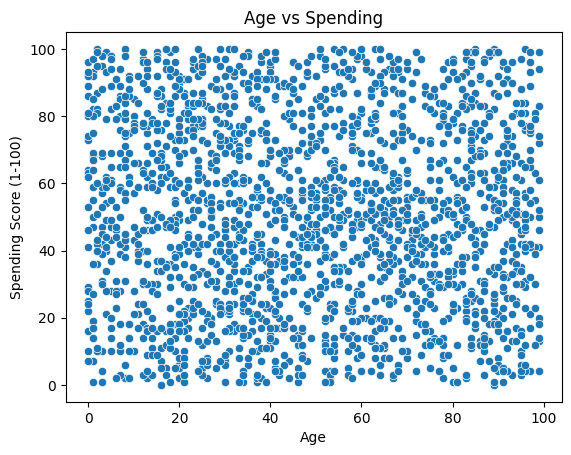

In [14]:
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)')
plt.title("Age vs Spending")
plt.show()

#Interpretation of Age vs Spending Behavior


The scatter plot shows no strong correlation between age and spending score.
Customers of all age groups exhibit both high and low spending patterns.
However, there is a slight concentration of higher spending among younger and middle-aged customers, suggesting they may be more engaged in discretionary purchases.
Older customers tend to show more moderate or lower spending behavior, though not exclusively.

#Conclusion
Age alone is not a strong predictor of customer spending behavior.

# 3. Profession vs Spending

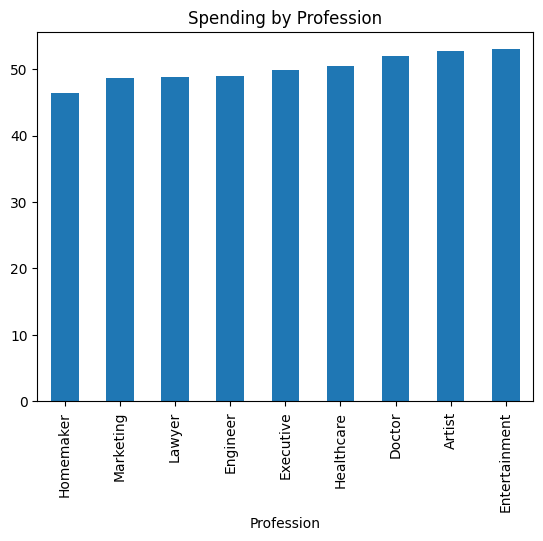

In [15]:
df.groupby('Profession')['Spending Score (1-100)'].mean().sort_values().plot(kind='bar')
plt.title("Spending by Profession")
plt.show()

#Interpretation of Spending by Profession

Certain professions such as Entertainment, Artist, and Doctor show higher average spending scores.
More traditional professions like Homemaker and Marketing tend to have slightly lower spending levels.
This suggests that lifestyle and profession influence spending behavior.

#Conclusion
Profession plays a moderate role in determining spending patterns.

# **OUTLIER DETECTION**

In [16]:
q1 = df['Annual Income ($)'].quantile(0.25)
q3 = df['Annual Income ($)'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = (df['Annual Income ($)'] < lower) | (df['Annual Income ($)'] > upper)

outliers.value_counts()

,count
Annual Income ($),
False,2000


# **CUSTOMER SEGMENTATION**

In [18]:
def segment_customer(row):
    if row['Annual Income ($)'] > 70000 and row['Spending Score (1-100)'] > 70:
        return 'High Value'
    elif row['Annual Income ($)'] > 70000 and row['Spending Score (1-100)'] < 40:
        return 'Rich but Low Spending'
    elif row['Annual Income ($)'] < 40000 and row['Spending Score (1-100)'] > 70:
        return 'Budget High Spenders'
    else:
        return 'Average'

df['Customer_Segment'] = df.apply(segment_customer, axis=1)

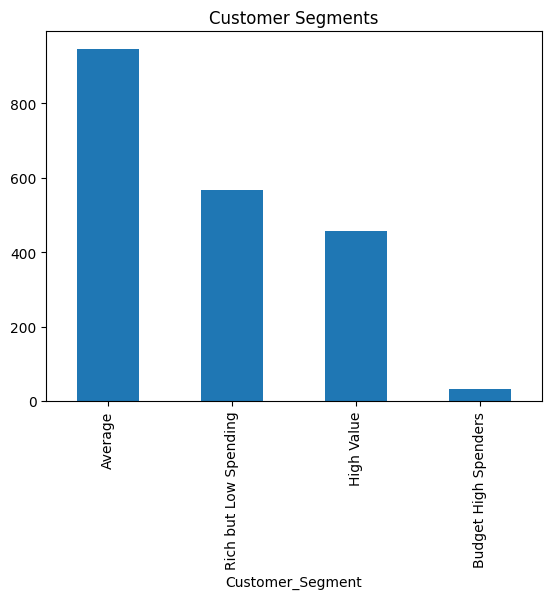

In [19]:
df['Customer_Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

# Interpretation of Customer Segmentation Analysis

The majority of customers fall into the “Average” segment, indicating balanced income and spending behavior.
A significant portion belongs to “Rich but Low Spending”, representing an untapped opportunity for businesses.
The “High Value” segment is smaller but extremely important, as these customers combine high income and high spending.
The “Budget High Spenders” group is the smallest, indicating fewer low-income customers with high spending tendencies.

#Conclusion
Customer segmentation reveals clear business opportunities, especially in targeting high-income low-spending customers.

#FINAL BUSINESS INSIGHTS

Businesses should focus marketing efforts on “Rich but Low Spending” customers to increase revenue.

Loyalty programs and personalized promotions can help convert these customers into high-value segments.

High-value customers should be retained through premium services and exclusive offers.

Since income alone does not determine spending, companies should use behavioral segmentation rather than demographic segmentation.